Import necessary libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl

Step 1: Load the image

In [2]:
image_url = "https://drive.google.com/uc?export=download&id=1kWIx5TR65nuAIThAUgcn31ccBsOgVQW-"
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

Step 2: Convert to Grayscale

In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

Step 3: HARRIS CORNER DETECTION

    Formula:
        R = det(M) - k * (trace(M)^2)
            where M is the second moment matrix:
                  M = [Ixx Ixy; Ixy Iyy], computed using image gradients

In [4]:
gray_float = np.float32(gray)
harris_response = cv2.cornerHarris(gray_float, 2, 3, 0.04)
harris_dilated = cv2.dilate(harris_response, None)
corner_thresh = 0.01 * harris_dilated.max()
harris_corners = harris_dilated > corner_thresh

harris_img = image.copy()
harris_img[harris_corners] = [0, 255, 0]  # Mark Harris corners in green

Step 4: DIFFERENCE OF GAUSSIAN (DoG)

In [5]:
# Apply Gaussian blurs with two different sigmas
blur1 = cv2.GaussianBlur(gray, (5, 5), 1)   # σ = 1
blur2 = cv2.GaussianBlur(gray, (5, 5), 2)   # σ = 2

# DoG = G(σ1) - G(σ2)
DoG = blur1 - blur2

# Normalize and find maxima (local extrema)
DoG_norm = cv2.normalize(DoG, None, 0, 255, cv2.NORM_MINMAX)
DoG_norm = np.uint8(DoG_norm)
_, DoG_thresh = cv2.threshold(DoG_norm, 15, 255, cv2.THRESH_BINARY)

DoG_output = cv2.bitwise_and(image, image, mask=DoG_thresh)

Step 5: INTENSITY-WEIGHTED FAST


In [6]:
# Use FAST detector
fast = cv2.FastFeatureDetector_create(threshold=25, nonmaxSuppression=True)
keypoints = fast.detect(gray, None)

# Weight keypoints by intensity (heuristic visualization)
fast_img = cv2.drawKeypoints(image, keypoints, None, color=(255, 0, 0))  # Red

Step 6: VISUALIZATION

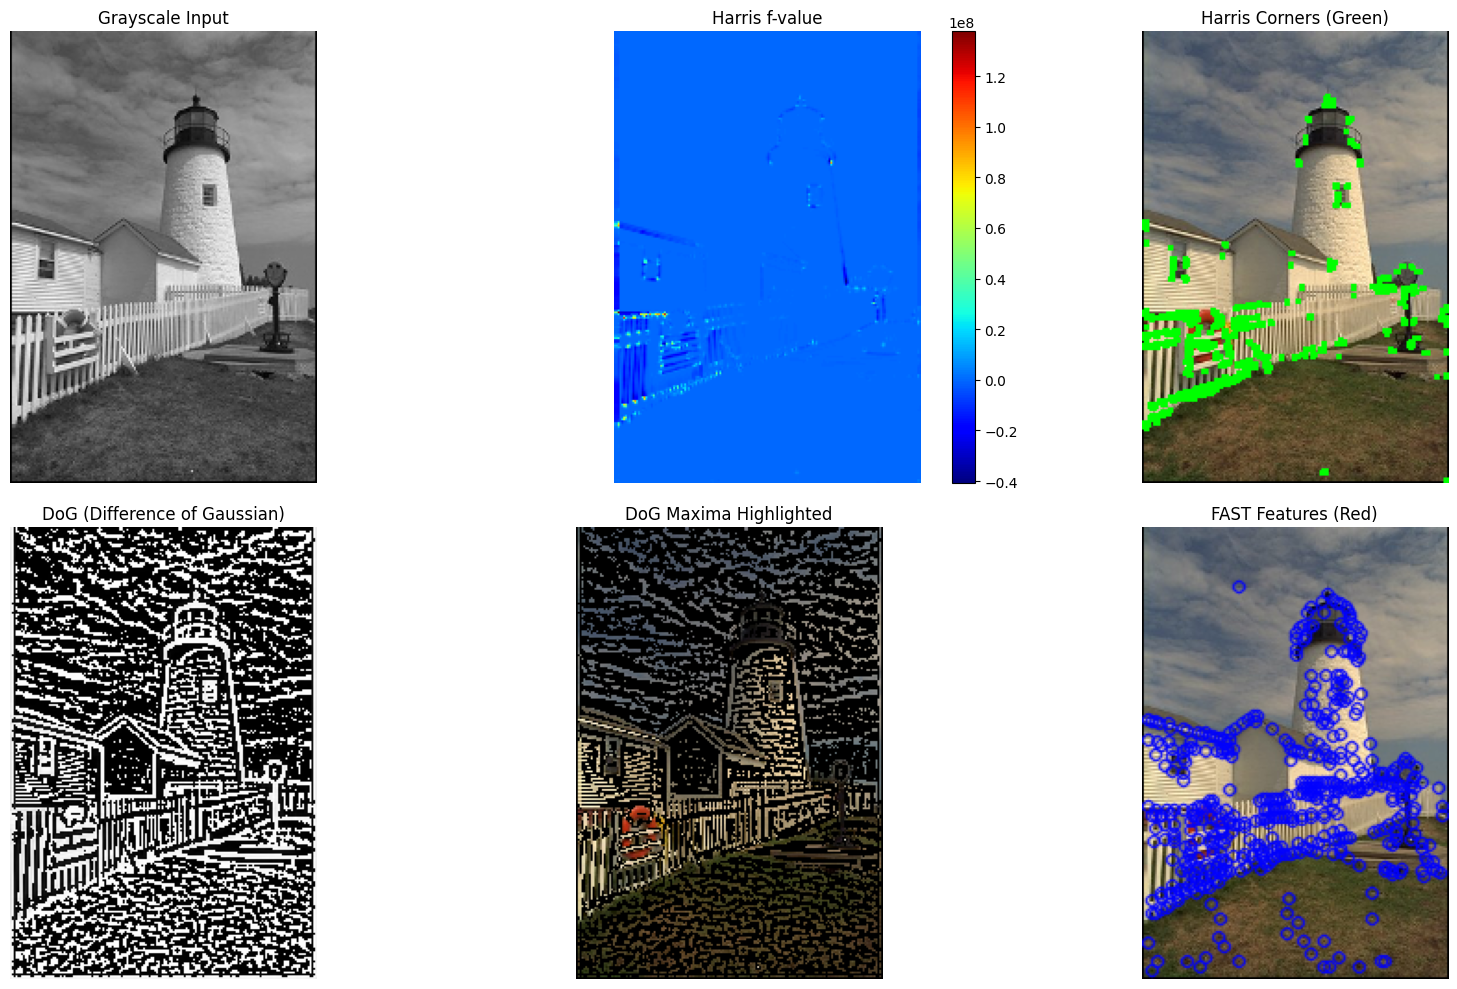

In [7]:
plt.figure(figsize=(18, 10))

# Original Grayscale
plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Input")
plt.axis('off')

# Harris f-value map
plt.subplot(2, 3, 2)
plt.imshow(harris_response, cmap='jet')
plt.title("Harris f-value")
plt.colorbar()
plt.axis('off')

# Harris Corners Marked
plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(harris_img, cv2.COLOR_BGR2RGB))
plt.title("Harris Corners (Green)")
plt.axis('off')

# DoG Output
plt.subplot(2, 3, 4)
plt.imshow(DoG, cmap='gray')
plt.title("DoG (Difference of Gaussian)")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(DoG_output, cv2.COLOR_BGR2RGB))
plt.title("DoG Maxima Highlighted")
plt.axis('off')

# FAST Keypoints
plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(fast_img, cv2.COLOR_BGR2RGB))
plt.title("FAST Features (Red)")
plt.axis('off')

plt.tight_layout()
plt.show()